# Hindi M-CDI CDI-I EDA and Norms
This notebook rebuilds the processed outputs with reusable project functions and then reviews CDI-I participant flow, characteristics, norm tables, figures, and interactive item trajectories.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
while not (repo_root / 'configs' / 'config.yaml').exists():
    repo_root = repo_root.parent
src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from hindibabynet_cdi import load_config, run_pipeline, render_item_widget

config = load_config(repo_root / 'configs' / 'config.yaml')
paths = run_pipeline(config)
processed_dir = config.paths.processed_data
outputs_dir = config.paths.outputs
paths


ModuleNotFoundError: No module named 'ipywidgets'

In [2]:
participant = pd.read_csv(processed_dir / 'participant_analysis_cdi1.csv')
items = pd.read_csv(processed_dir / 'cdi1_items_long.csv')
flow = pd.read_csv(outputs_dir / 'tables' / 'qc' / 'participant_flow.csv')
exclusions = pd.read_csv(outputs_dir / 'tables' / 'qc' / 'exclusions.csv')
characteristics = pd.read_csv(outputs_dir / 'tables' / 'qc' / 'sample_characteristics.csv')
mapping_validation = pd.read_csv(processed_dir / 'item_mapping_validation.csv')
completeness = pd.read_csv(outputs_dir / 'tables' / 'qc' / 'completeness_report.csv')
norms_comp = pd.read_csv(outputs_dir / 'tables' / 'cdi1' / 'cdi1_comprehension_norms.csv')
norms_prod = pd.read_csv(outputs_dir / 'tables' / 'cdi1' / 'cdi1_production_norms.csv')
sex_comp = pd.read_csv(outputs_dir / 'tables' / 'cdi1' / 'cdi1_comprehension_sex.csv')
sex_prod = pd.read_csv(outputs_dir / 'tables' / 'cdi1' / 'cdi1_production_sex.csv')
education_comp = pd.read_csv(outputs_dir / 'tables' / 'cdi1' / 'cdi1_comprehension_education.csv')
education_prod = pd.read_csv(outputs_dir / 'tables' / 'cdi1' / 'cdi1_production_education.csv')
included = participant.loc[participant['included_final'] == True].copy()
included.head()


,participant_id,form,sex,mother_education,hindi_percentage,included_final,expected_form,age_form_match,primary_exclusion_reason,all_exclusion_reasons,...,production_total,age_months_exact,age_month,cdi_submission_id,n_items_expected,n_items_present,n_nonblank_responses,trailing_blank_run,completion_status,cdi_is_complete_enough
0,P000003,CDI-I,male,some_college,91.0,True,CDI-I,True,NaN,NaN,...,230,12.123203,12,37873660,409,409,408,0,complete,True
2,P000009,CDI-I,female,bachelor,92.0,True,CDI-I,True,NaN,NaN,...,135,12.780287,12,37914149,409,409,409,0,complete,True
3,P000011,CDI-I,female,some_college,98.0,True,CDI-I,True,NaN,NaN,...,7,8.870637,8,37917682,409,409,406,0,complete,True
5,P000014,CDI-I,female,some_college,99.0,True,CDI-I,True,NaN,NaN,...,86,13.141684,13,37939989,409,409,409,0,complete,True
7,P000018,CDI-I,male,bachelor,93.0,True,CDI-I,True,NaN,NaN,...,26,11.466119,11,37945016,409,409,409,0,complete,True


## Sample Flow and Exclusions


In [3]:
flow


,Stage,CDI-I,CDI-II,Total
0,Raw CDI submissions,141,165,306
1,Successfully linked to background,141,165,306
2,Successfully linked to eligibility,141,165,306
3,Successfully linked to consent,141,165,306
4,Consent provided,133,154,287
5,Eligibility passed,141,165,306
6,Hindi exposure >75%,140,160,300
7,Age matches form,103,140,243
8,Passed completeness check,141,165,306
9,Final included participants,98,129,227


In [4]:
exclusions


,Exclusion reason,CDI-I,CDI-II,Total
0,No consent,8,11,19
1,Broken reference chain,0,0,0
2,Failed eligibility,0,0,0
3,Hindi exposure ≤75%,0,3,3
4,Hindi exposure unknown,0,2,2
5,Age outside form range,35,20,55
6,Incomplete CDI,0,0,0


## Participant Characteristics


In [5]:
characteristics.loc[characteristics['form'] == 'CDI-I']


,form,Variable,Value
0,CDI-I,N,98
1,CDI-I,"Age, mean (SD)",12.69 (2.93)
2,CDI-I,"Age, median [IQR]","12.71 [9.97, 14.97]"
3,CDI-I,Age range,8.05-18.37
4,CDI-I,"Hindi exposure, mean (SD)",92.94 (3.27)
5,CDI-I,"Female, n (%)",0 (0.0%)
6,CDI-I,"Male, n (%)",0 (0.0%)
7,CDI-I,"Mother's education: primary_school, n (%)",14 (14.3%)
8,CDI-I,"Mother's education: high_school, n (%)",28 (28.6%)
9,CDI-I,"Mother's education: some_college, n (%)",38 (38.8%)


In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display

if 'participant' not in globals():
    repo_root = Path.cwd()
    while not (repo_root / 'configs' / 'config.yaml').exists():
        repo_root = repo_root.parent
    participant = pd.read_csv(repo_root / 'data' / 'processed' / 'participant_analysis_cdi1.csv')

if 'included' not in globals():
    included = participant.loc[participant['included_final'] == True].copy()

sex_counts = pd.concat(
    {
        'actual_data': participant['sex'].value_counts().sort_index(),
        'included_data': included['sex'].value_counts().sort_index(),
    },
    axis=1,
).fillna(0).astype(int)
sex_counts.index.name = 'child_sex'

mother_education_counts = pd.concat(
    {
        'actual_data': participant['mother_education'].value_counts().sort_index(),
        'included_data': included['mother_education'].value_counts().sort_index(),
    },
    axis=1,
).fillna(0).astype(int)
mother_education_counts.index.name = 'mother_education'

print('Child sex counts')
display(sex_counts)
print('Maternal education counts')
display(mother_education_counts)


Child sex counts


,actual_data,included_data
child_sex,,
female,72,52
male,69,46


Maternal education counts


,actual_data,included_data
mother_education,,
bachelor,29,18
high_school,44,28
primary_school,16,14
some_college,52,38


## Missingness and QC


In [6]:
completeness.loc[completeness['form'] == 'CDI-I', 'completion_status'].value_counts().to_frame('n')


,n
completion_status,
complete,132
trailing_blank_block,9


In [7]:
mapping_validation['issue_type'].value_counts().to_frame('n')


,n
issue_type,
normalization_only_match,934
duplicate_hindi_label_within_form,32
observed_column_absent_from_mapping,3


## Age Distribution and Sample Size by Age


In [8]:
included.groupby('age_month').size().to_frame('n')


,n
age_month,
8,14
9,11
10,7
11,10
12,10
13,10
14,12
15,7
16,12


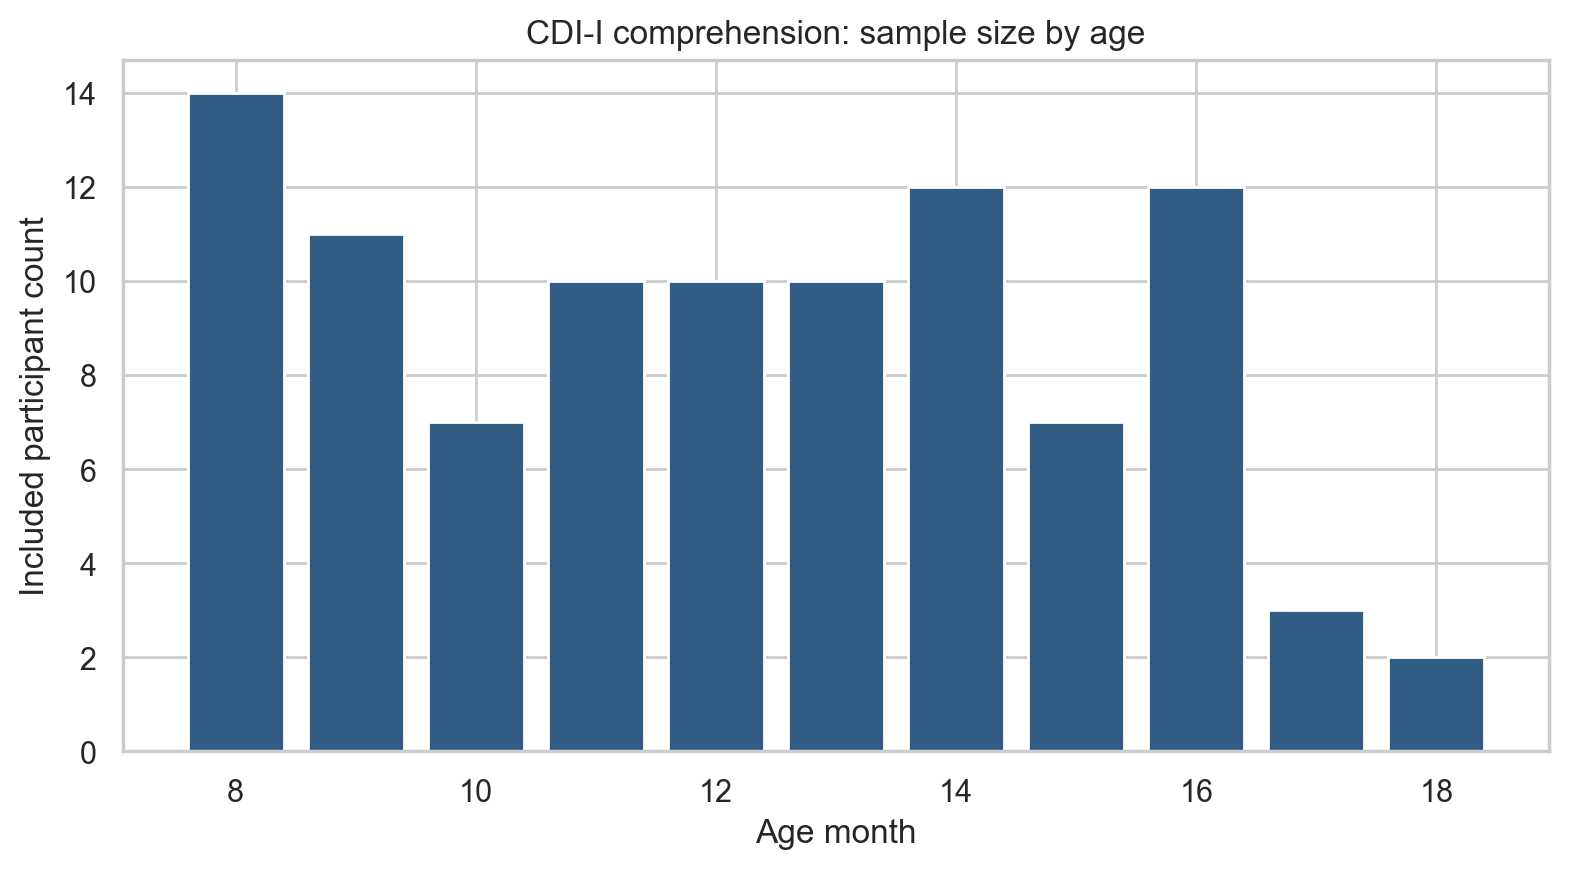

In [9]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'comprehension' / 'cdi1_comprehension_sample_size.png'))


## Score Summaries


In [10]:
included[['comprehension_total', 'production_total']].describe().T


,count,mean,std,min,25%,50%,75%,max
comprehension_total,98.0,150.969388,147.272064,3.0,42.25,77.5,211.25,409.0
production_total,98.0,40.887755,82.734812,0.0,0.25,4.0,35.50,408.0


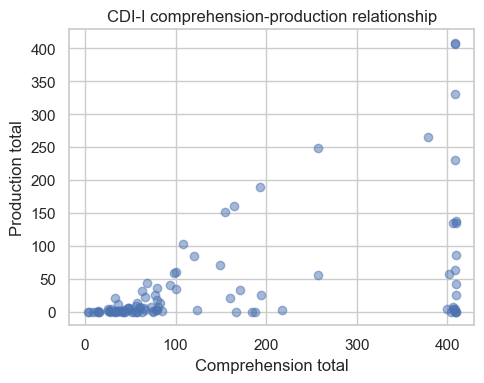

In [11]:
plt.figure(figsize=(5, 4))
plt.scatter(included['comprehension_total'], included['production_total'], alpha=0.5)
plt.xlabel('Comprehension total')
plt.ylabel('Production total')
plt.title('CDI-I comprehension-production relationship')
plt.tight_layout()
plt.show()


## Empirical Norm Tables


In [12]:
norms_comp


,age_month,n,mean,sd,min,max,p10,p20,p25,p30,p40,p50,p60,p70,p75,p80,p90
0,8,14,128.928571,159.605024,3.0,408.0,11.0,26.8,29.50,33.4,34.6,44.5,60.8,98.2,184.00,292.6,407.4
1,9,11,91.181818,123.639652,9.0,400.0,13.0,28.0,28.50,29.0,32.0,37.0,41.0,78.0,78.50,79.0,257.0
2,10,7,178.000000,164.865602,43.0,409.0,50.8,58.0,61.00,64.0,69.6,75.0,142.8,232.2,298.50,364.8,409.0
3,11,10,130.600000,146.761485,49.0,409.0,49.9,53.2,54.75,56.1,59.4,64.5,70.0,74.2,76.00,143.2,408.1
4,12,10,246.500000,174.235632,28.0,409.0,61.3,76.2,79.25,79.7,134.6,289.5,408.0,408.0,408.00,408.2,409.0
5,13,10,128.800000,153.101854,14.0,409.0,14.9,15.0,20.25,29.7,54.0,70.5,82.6,113.8,143.50,208.8,404.5
6,14,12,123.833333,67.574650,25.0,257.0,45.3,61.8,75.00,86.1,106.8,122.0,142.6,161.3,164.75,166.4,191.3
7,15,7,130.714286,124.366011,33.0,378.0,38.4,45.0,49.50,54.0,59.4,63.0,114.6,157.8,171.00,184.2,267.0
8,16,12,181.333333,167.887589,33.0,409.0,38.4,43.0,45.75,57.8,89.8,100.5,105.2,313.8,403.00,405.2,406.9
9,17,3,287.000000,207.848503,47.0,408.0,118.8,190.6,226.50,262.4,334.2,406.0,406.4,406.8,407.00,407.2,407.6


In [13]:
norms_prod


,age_month,n,mean,sd,min,max,p10,p20,p25,p30,p40,p50,p60,p70,p75,p80,p90
0,8,14,59.214286,147.565463,0.0,408.0,0.0,0.0,0.00,0.0,1.0,1.0,1.0,1.1,1.75,4.0,287.0
1,9,11,7.272727,16.156057,0.0,55.0,0.0,0.0,0.00,0.0,1.0,2.0,3.0,4.0,4.00,4.0,11.0
2,10,7,21.142857,51.193843,0.0,137.0,0.0,0.0,0.00,0.0,0.0,0.0,1.2,3.4,5.50,7.6,60.2
3,11,10,44.700000,101.288422,0.0,330.0,0.0,1.6,2.75,4.1,6.2,7.0,14.6,26.0,26.00,29.6,72.6
4,12,10,46.100000,76.465606,0.0,230.0,0.0,0.0,1.00,2.8,4.6,11.5,24.0,33.9,35.25,55.8,144.5
5,13,10,17.400000,27.933254,0.0,86.0,0.0,0.0,0.25,0.7,1.0,1.0,9.0,21.6,22.50,26.6,45.5
6,14,12,62.916667,82.363340,0.0,249.0,0.2,2.4,3.50,4.9,9.4,19.0,45.4,76.5,100.75,137.6,160.0
7,15,7,79.857143,105.918882,0.0,265.0,0.6,1.2,1.50,1.8,13.6,31.0,55.0,94.6,130.00,165.4,219.4
8,16,12,39.500000,43.029588,1.0,134.0,1.1,2.6,4.25,7.4,16.2,27.5,38.8,53.2,58.50,59.6,98.7
9,17,3,24.666667,34.078341,4.0,64.0,4.4,4.8,5.00,5.2,5.6,6.0,17.6,29.2,35.00,40.8,52.4


In [14]:
sex_comp.head(20)


,age_month,sex,n,mean,median,p10,p25,p50,p75,p90
0,8,female,5,190.400000,85.0,26.2,28.00,85.0,406.00,407.2
1,8,male,9,94.777778,37.0,4.6,34.00,37.0,63.00,255.2
2,9,female,3,99.333333,28.0,16.0,20.50,28.0,142.50,211.2
3,9,male,8,88.125000,39.0,23.0,31.25,39.0,78.25,175.3
4,10,female,4,174.000000,122.0,46.9,52.75,122.0,243.25,342.7
5,10,male,3,183.333333,75.0,67.8,70.50,75.0,242.00,342.2
6,11,female,3,53.666667,54.0,50.8,52.00,54.0,55.50,56.4
7,11,male,7,163.571429,73.0,56.2,64.50,73.0,242.50,408.4
8,12,female,5,266.400000,408.0,48.4,79.00,408.0,408.00,408.6
9,12,male,5,226.600000,171.0,71.0,80.00,171.0,408.00,408.6


In [15]:
sex_prod.head(20)


,age_month,sex,n,mean,median,p10,p25,p50,p75,p90
0,8,female,5,83.600000,1.0,1.0,1.00,1.0,7.0,247.6
1,8,male,9,45.666667,0.0,0.0,0.00,0.0,1.0,83.0
2,9,female,3,18.666667,1.0,0.2,0.50,1.0,28.0,44.2
3,9,male,8,3.000000,2.5,0.0,0.00,2.5,4.0,6.1
4,10,female,4,36.500000,4.5,0.0,0.00,4.5,41.0,98.6
5,10,male,3,0.666667,0.0,0.0,0.00,0.0,1.0,1.6
6,11,female,3,0.666667,0.0,0.0,0.00,0.0,1.0,1.6
7,11,male,7,63.571429,26.0,6.2,7.00,26.0,35.0,158.4
8,12,female,5,31.400000,4.0,0.0,0.00,4.0,18.0,88.2
9,12,male,5,60.800000,33.0,2.0,5.00,33.0,36.0,152.4


In [16]:
education_comp.head(20)


,age_month,mother_education,n,mean,median,p25,p50,p75
0,8,high_school,8,59.750000,40.0,20.00,40.0,68.50
1,8,primary_school,3,158.666667,34.0,34.00,34.0,221.00
2,8,some_college,3,283.666667,406.0,221.50,406.0,407.00
3,9,bachelor,4,37.250000,28.5,24.25,28.5,41.50
4,9,high_school,1,41.000000,41.0,41.00,41.0,41.00
5,9,primary_school,1,37.000000,37.0,37.00,37.0,37.00
6,9,some_college,5,155.200000,78.0,32.00,78.0,257.00
7,10,bachelor,1,409.000000,409.0,409.00,409.0,409.00
8,10,high_school,3,99.000000,66.0,54.50,66.0,127.00
9,10,some_college,3,180.000000,75.0,65.50,75.0,242.00


In [17]:
education_prod.head(20)


,age_month,mother_education,n,mean,median,p25,p50,p75
0,8,high_school,8,0.625000,0.5,0.00,0.5,1.00
1,8,primary_school,3,136.333333,1.0,0.50,1.0,204.50
2,8,some_college,3,138.333333,7.0,4.00,7.0,207.00
3,9,bachelor,4,1.750000,1.5,0.75,1.5,2.50
4,9,high_school,1,0.000000,0.0,0.00,0.0,0.00
5,9,primary_school,1,11.000000,11.0,11.00,11.0,11.00
6,9,some_college,5,12.400000,3.0,0.00,3.0,4.00
7,10,bachelor,1,0.000000,0.0,0.00,0.0,0.00
8,10,high_school,3,0.666667,0.0,0.00,0.0,1.00
9,10,some_college,3,48.666667,9.0,4.50,9.0,73.00


## Comprehension Figures


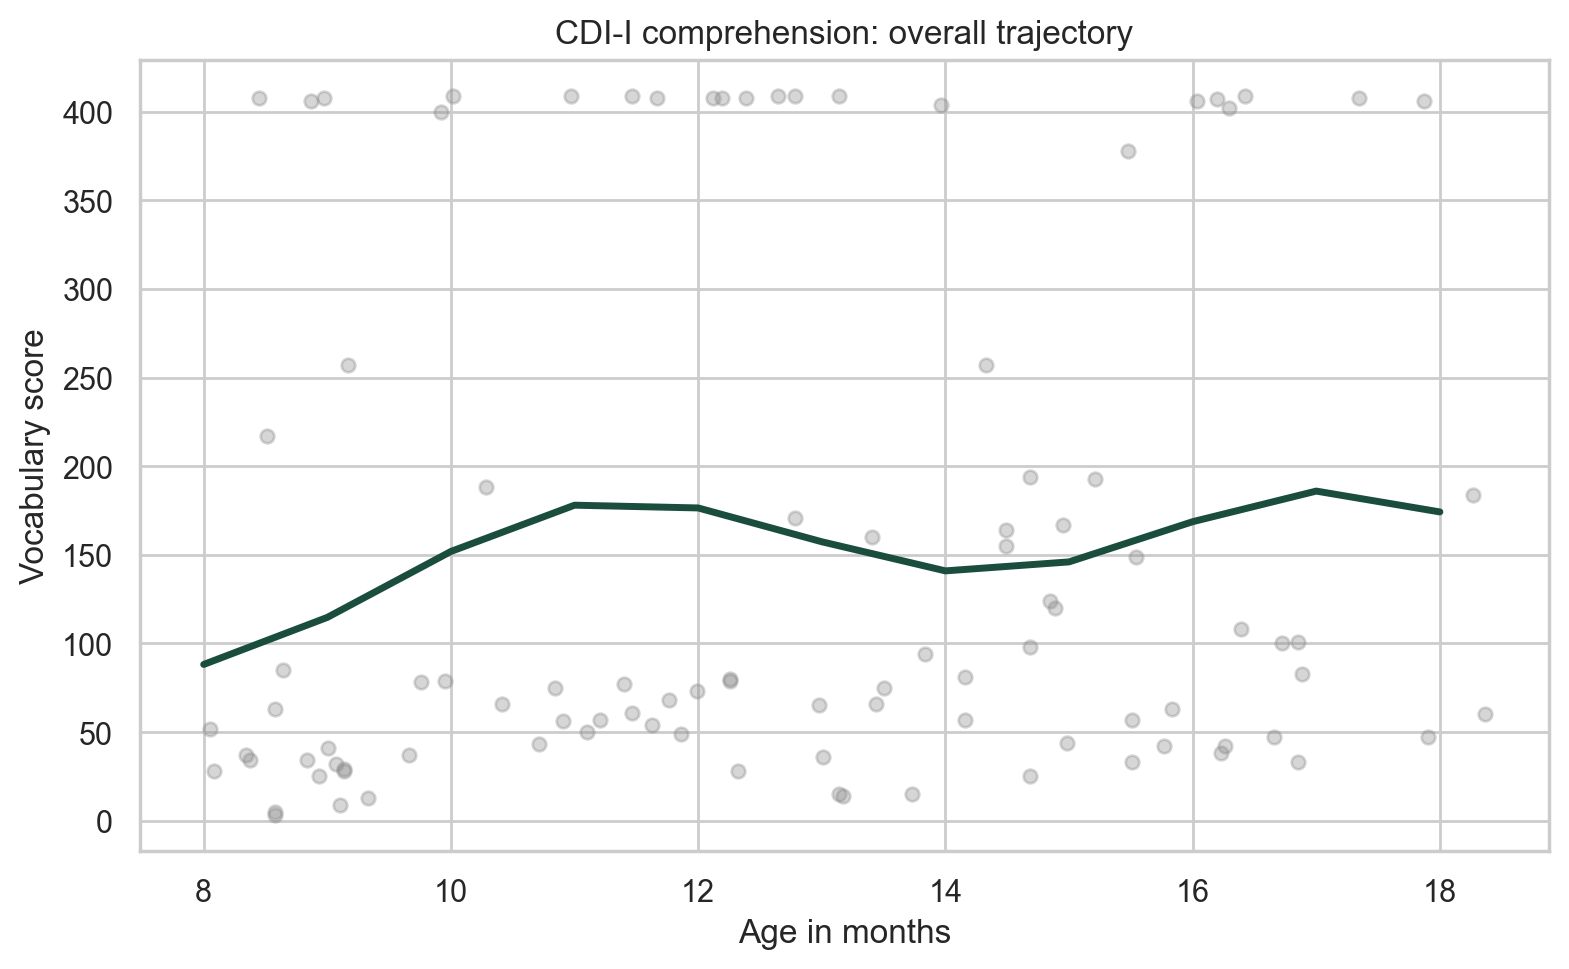

In [18]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'comprehension' / 'cdi1_comprehension_overall.png'))


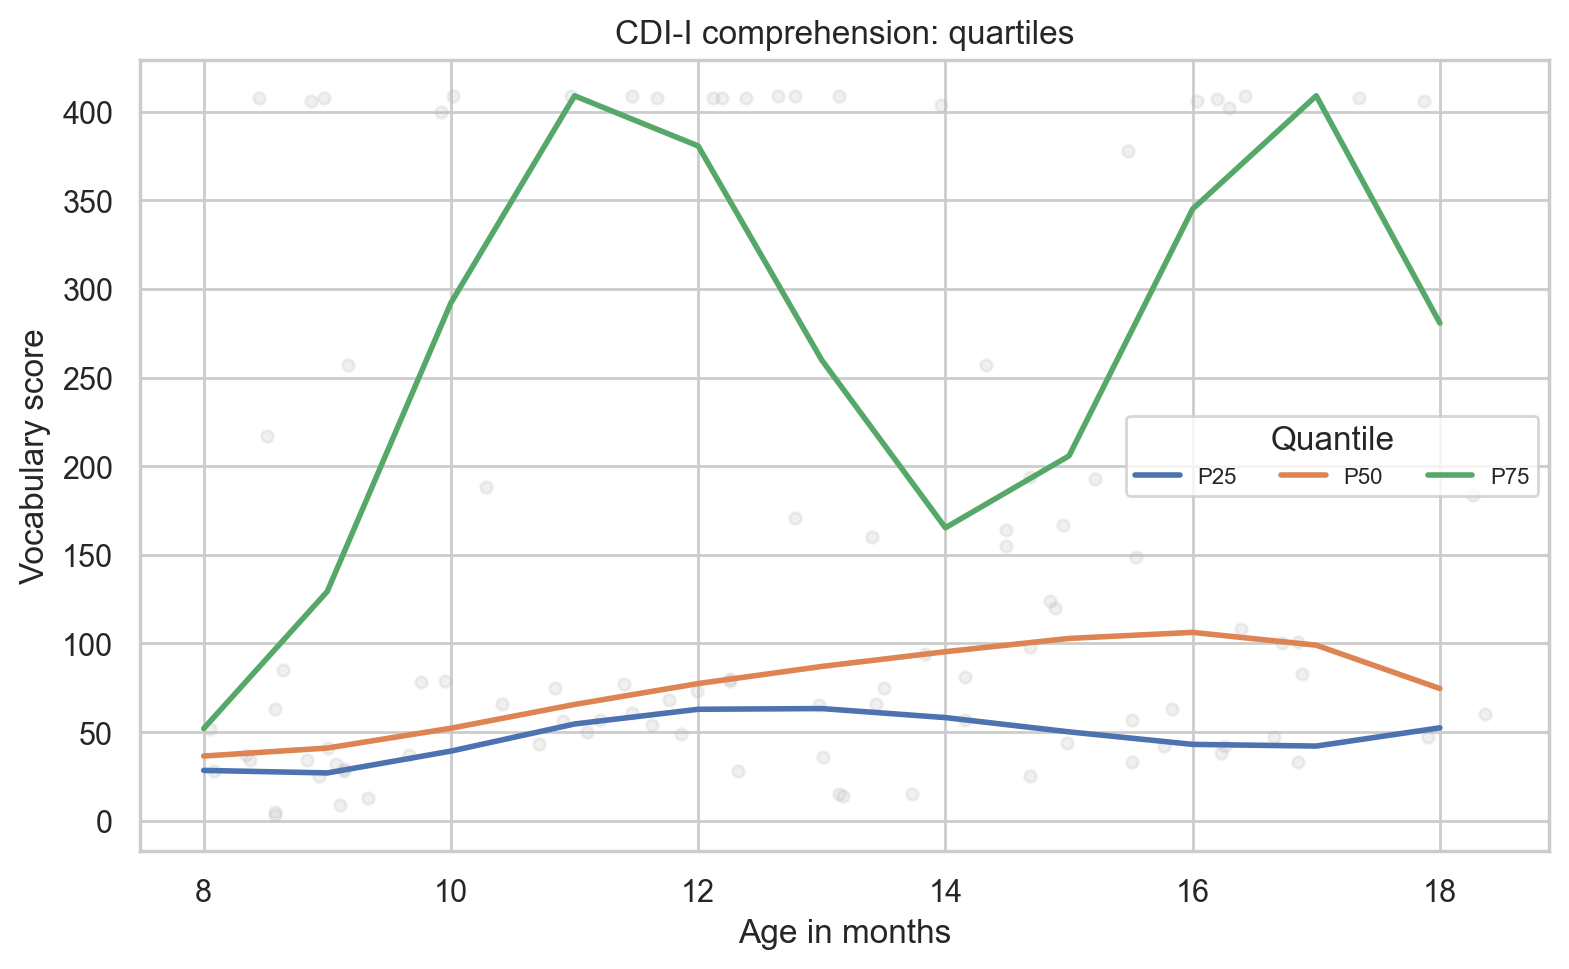

In [19]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'comprehension' / 'cdi1_comprehension_quartiles.png'))


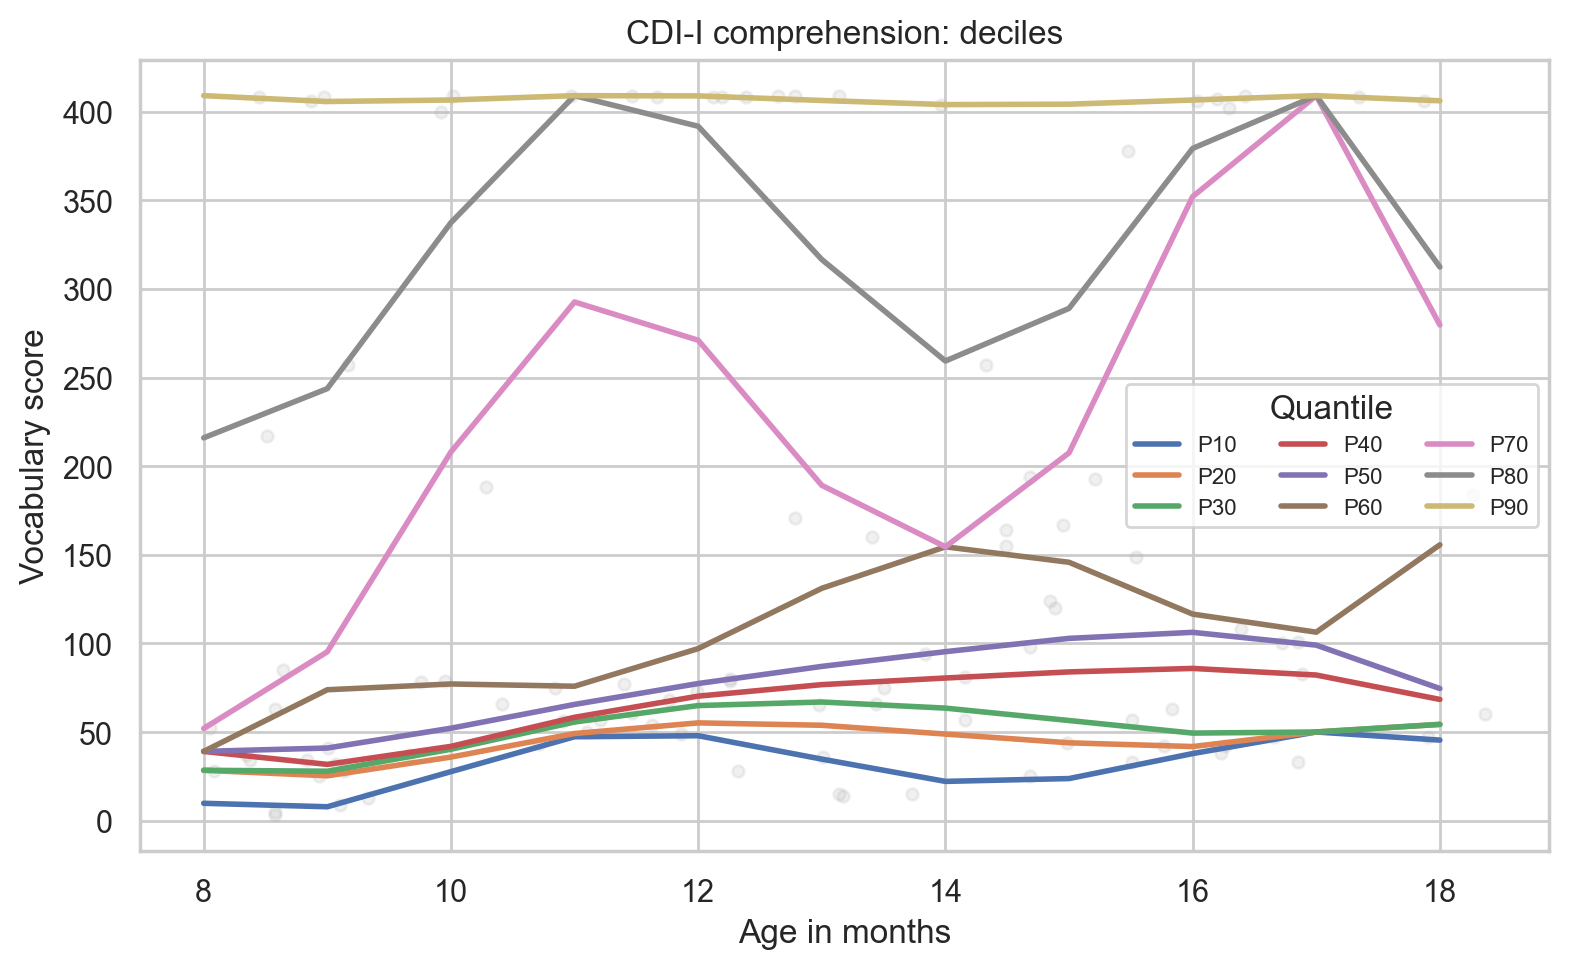

In [20]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'comprehension' / 'cdi1_comprehension_deciles.png'))


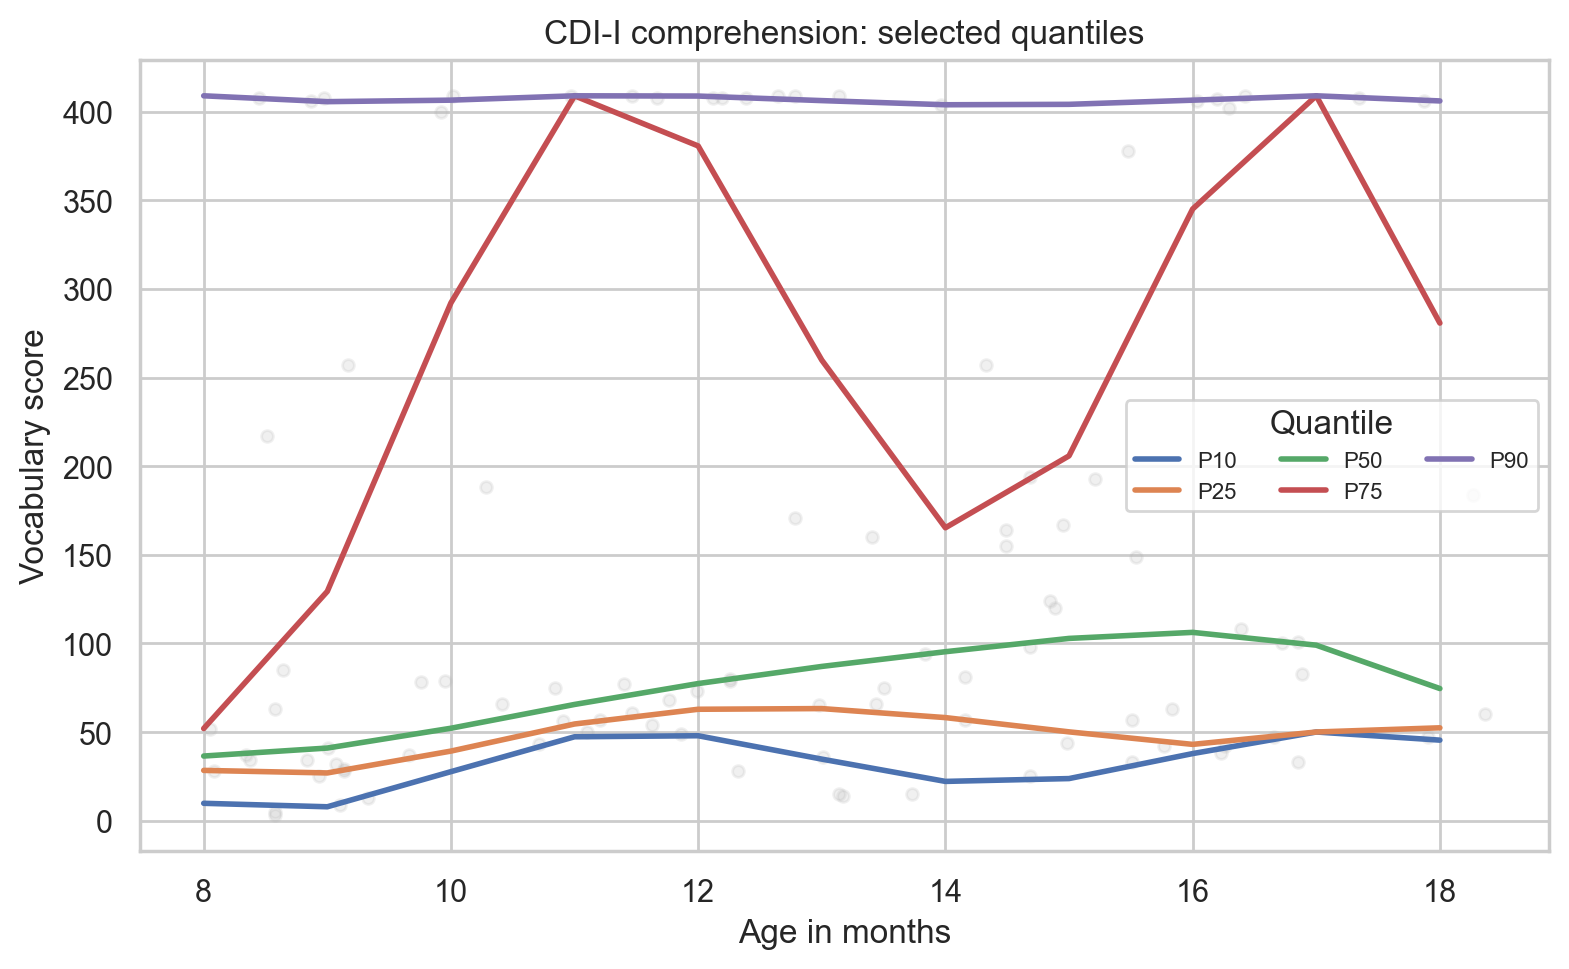

In [21]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'comprehension' / 'cdi1_comprehension_selected_quantiles.png'))


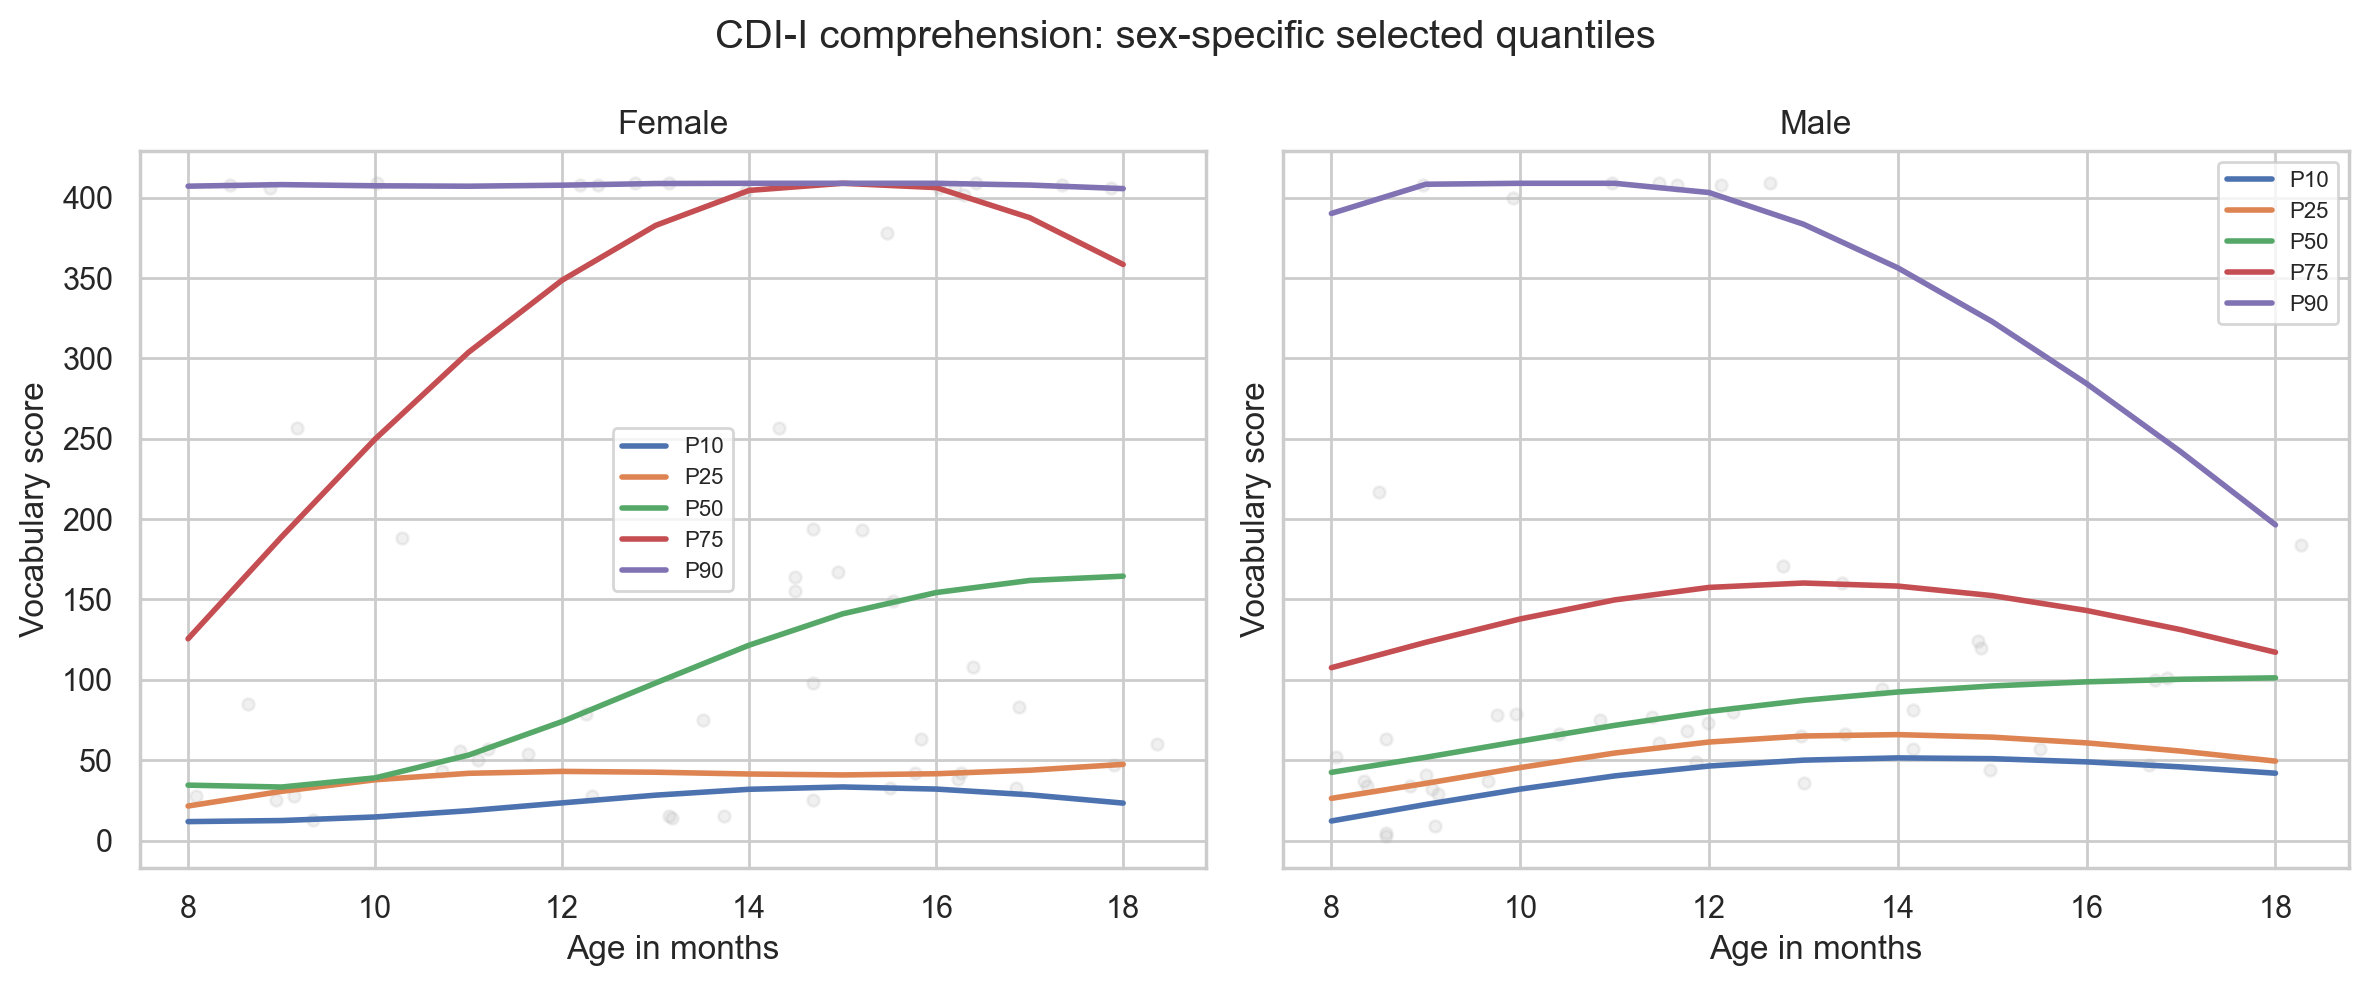

In [22]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'comprehension' / 'cdi1_comprehension_sex_selected_quantiles.png'))


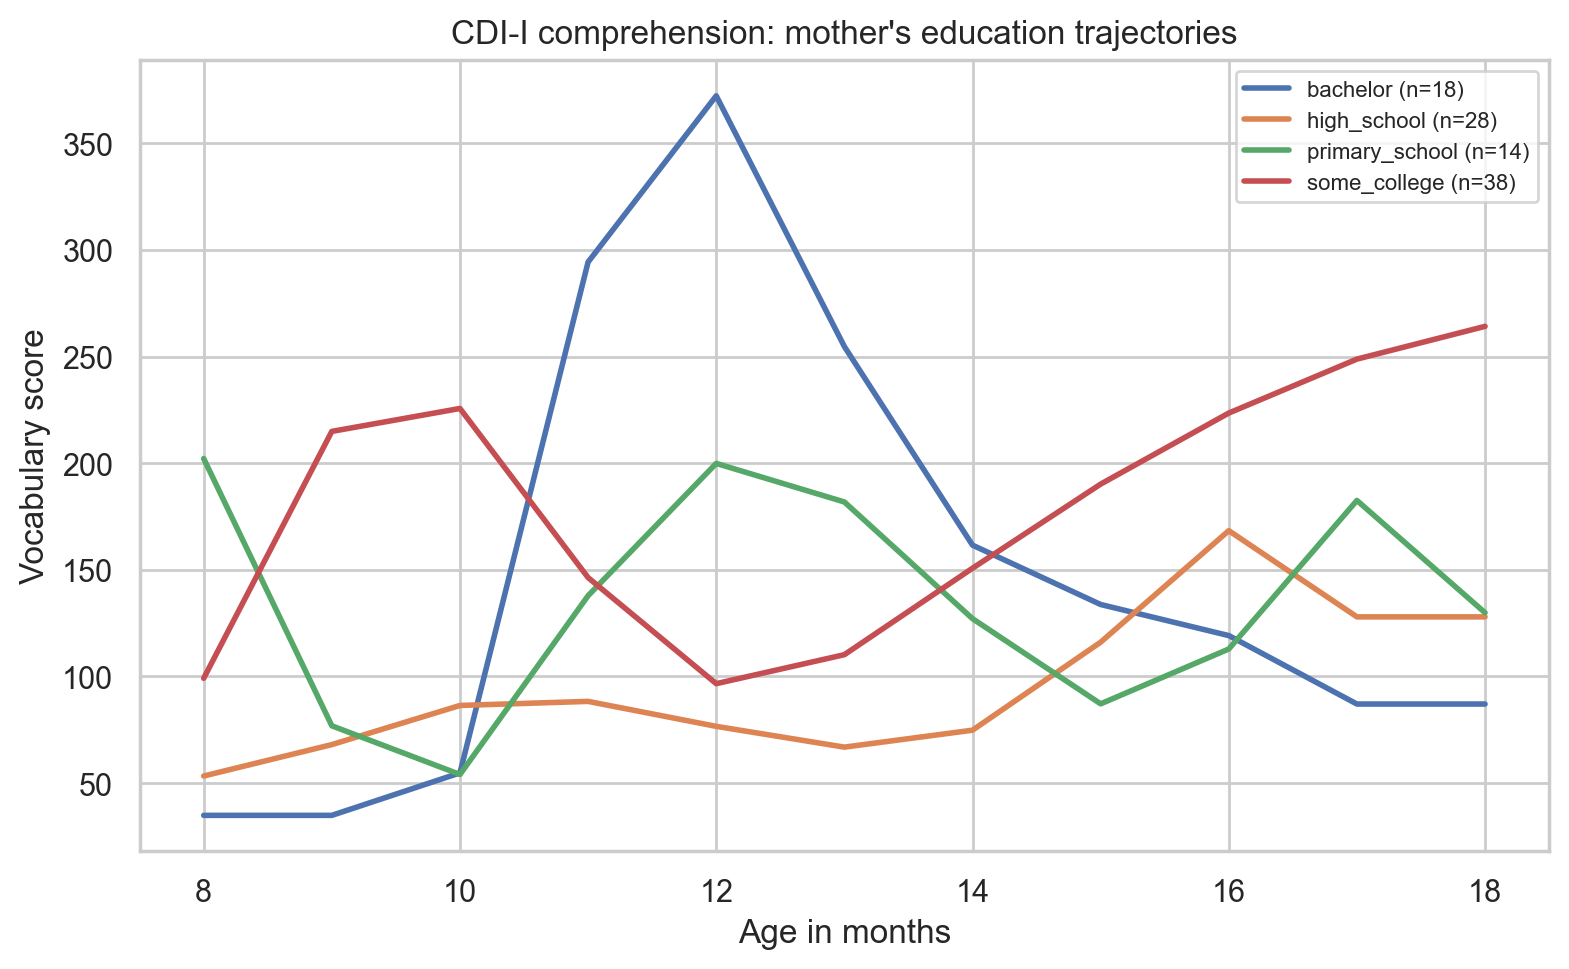

In [23]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'categories' / 'cdi1_comprehension_education.png'))


## Production Figures


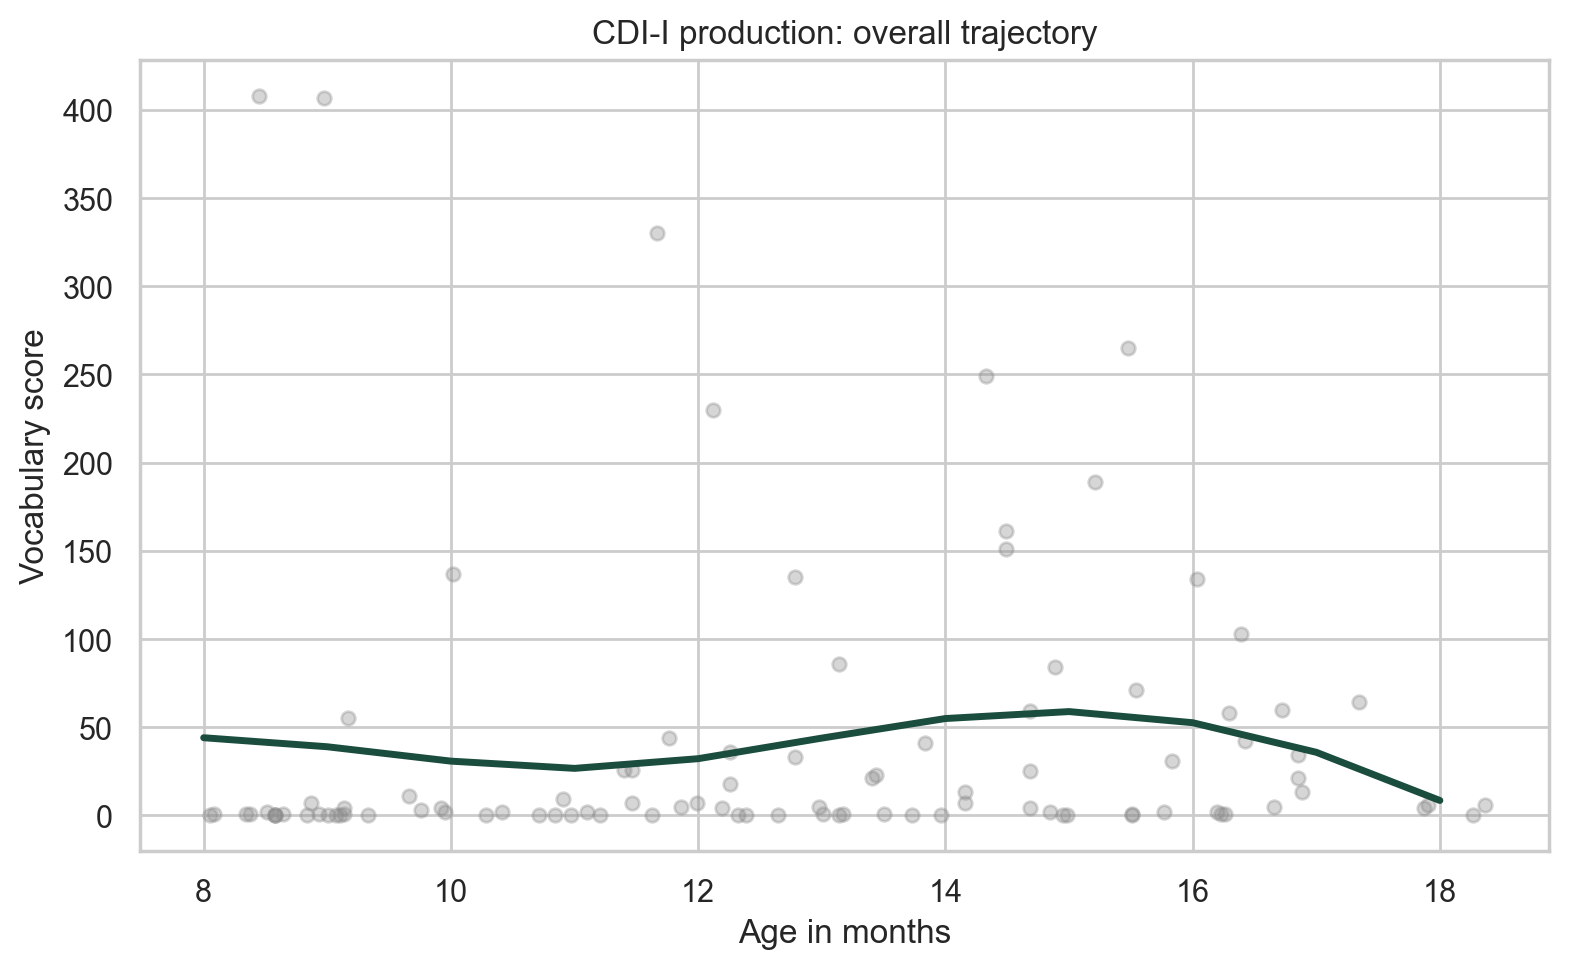

In [24]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'production' / 'cdi1_production_overall.png'))


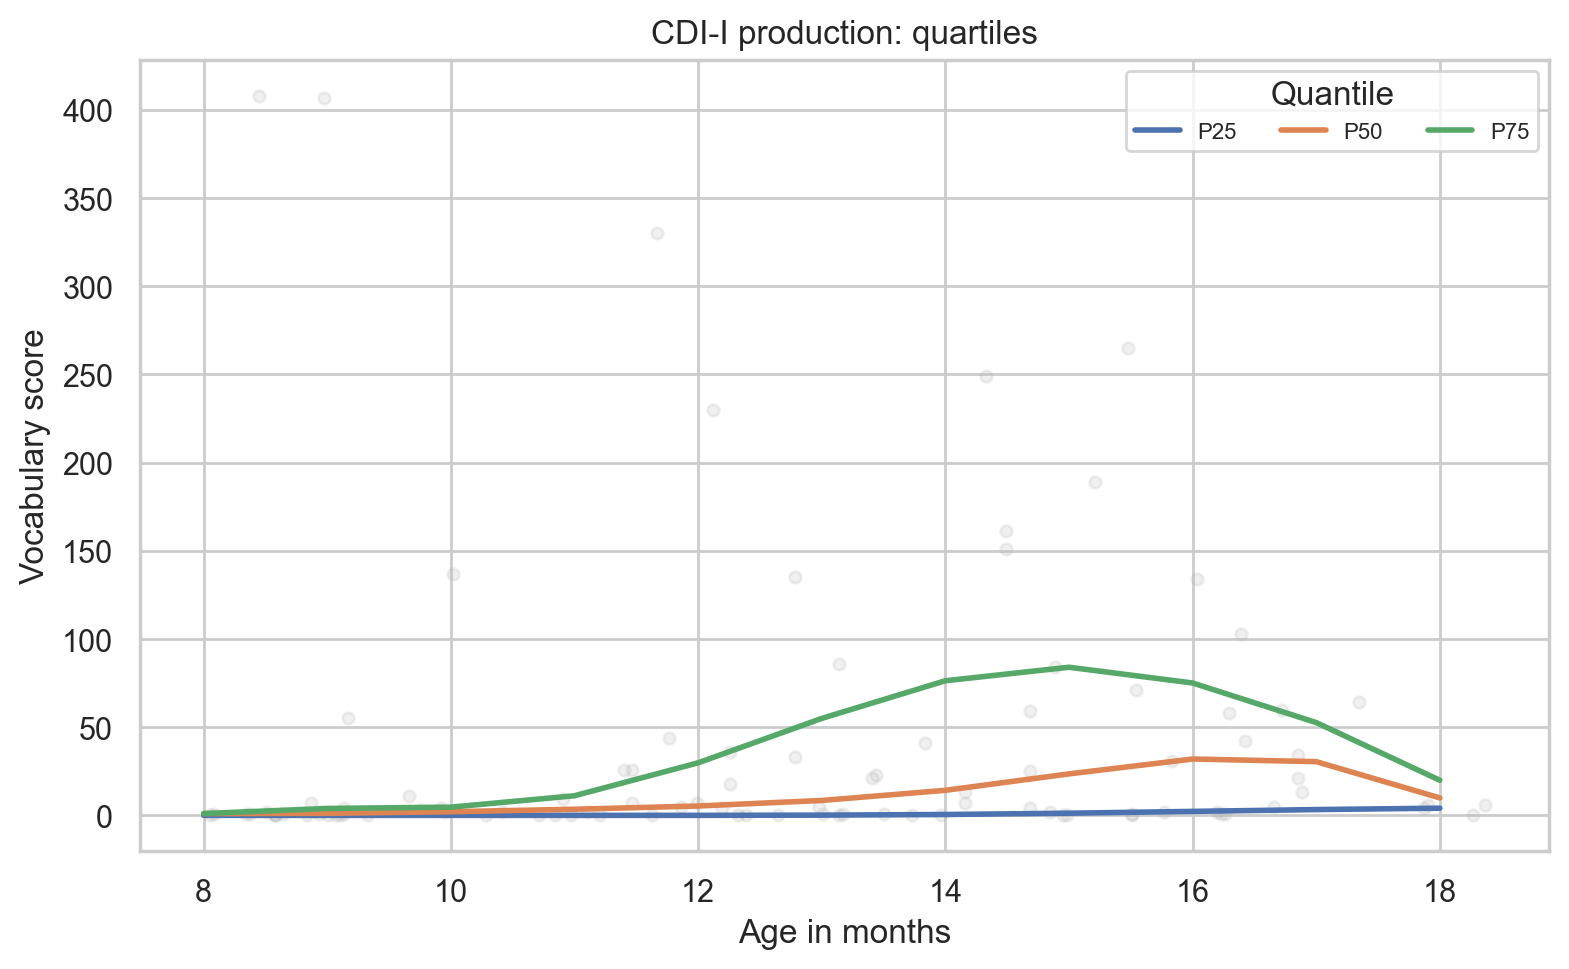

In [25]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'production' / 'cdi1_production_quartiles.png'))


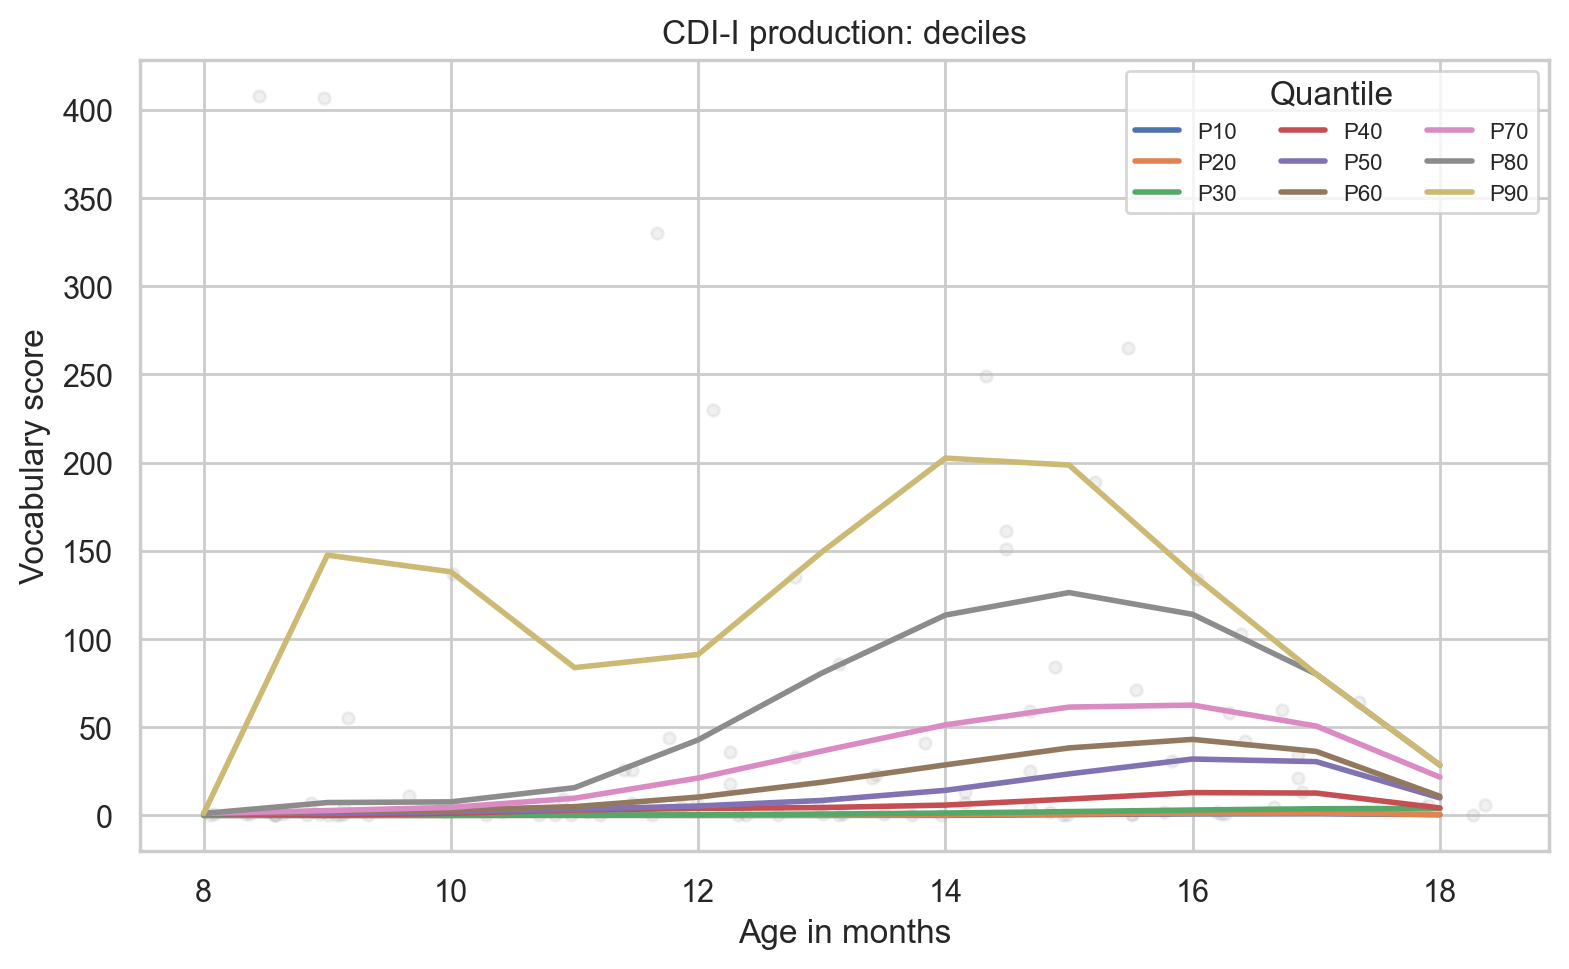

In [26]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'production' / 'cdi1_production_deciles.png'))


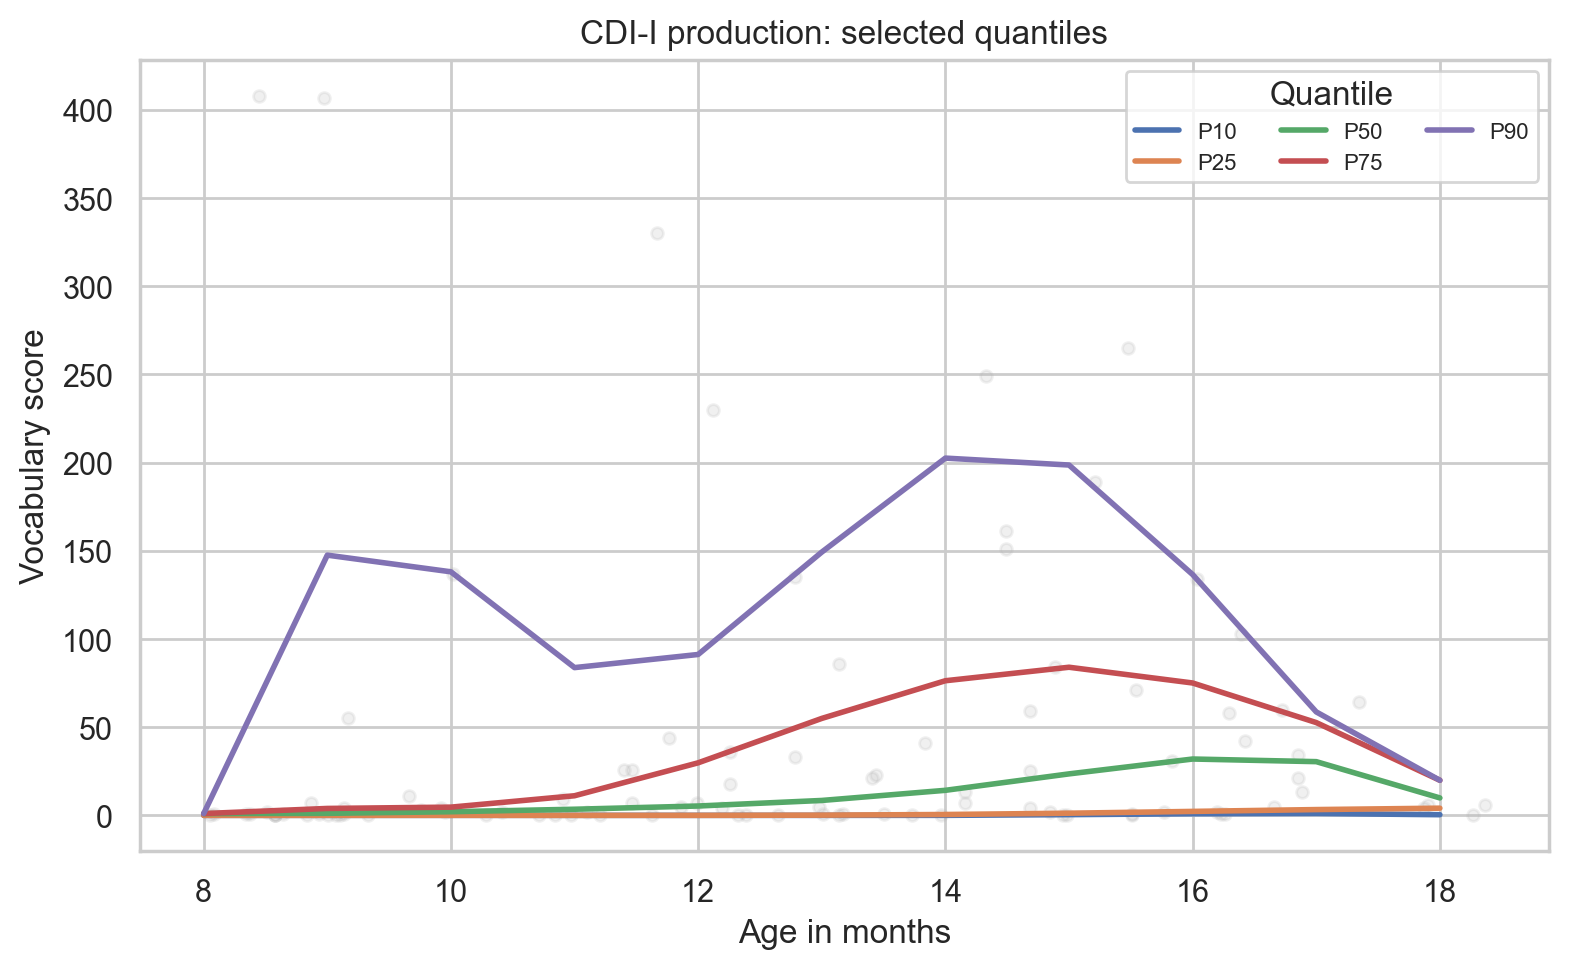

In [27]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'production' / 'cdi1_production_selected_quantiles.png'))


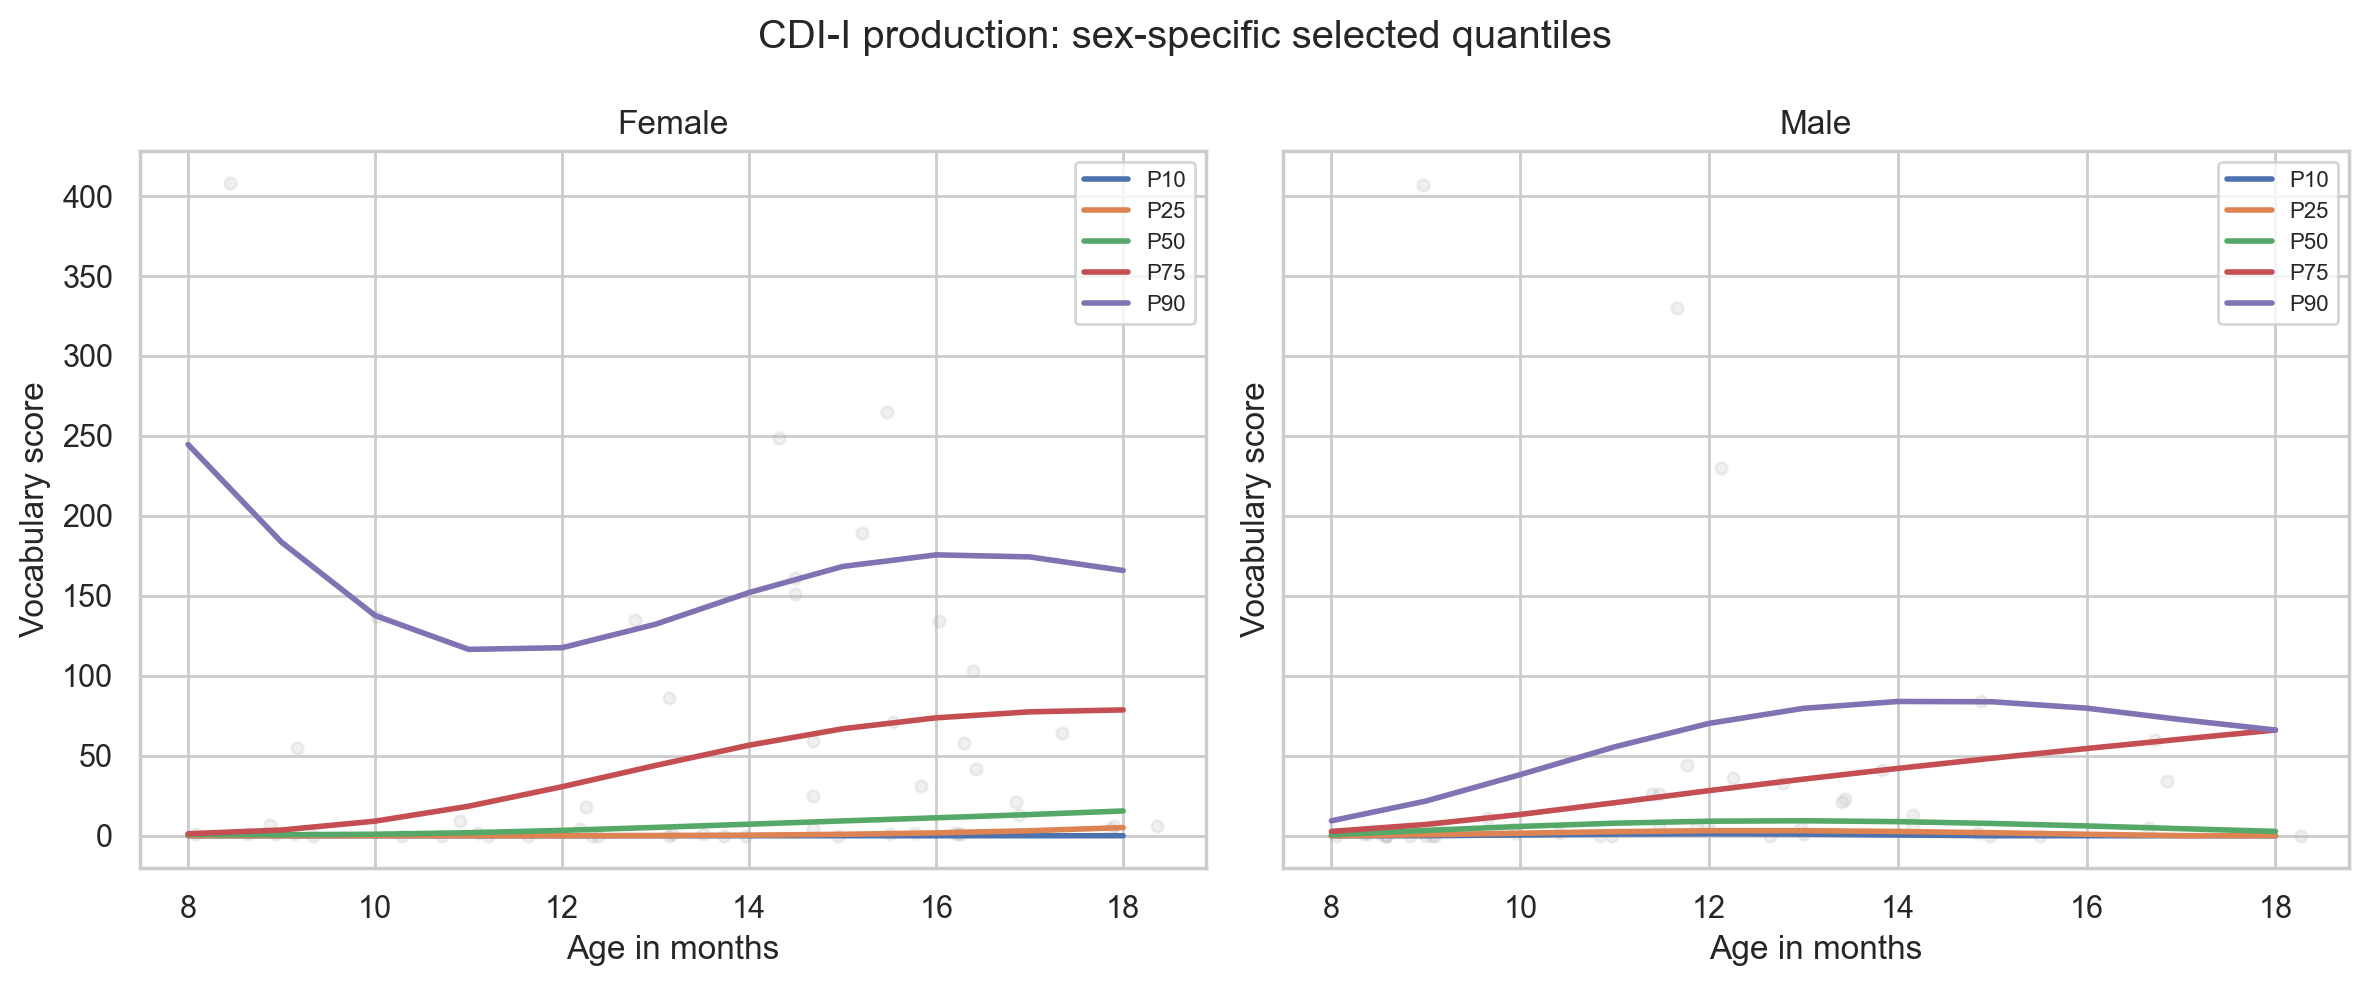

In [28]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'production' / 'cdi1_production_sex_selected_quantiles.png'))


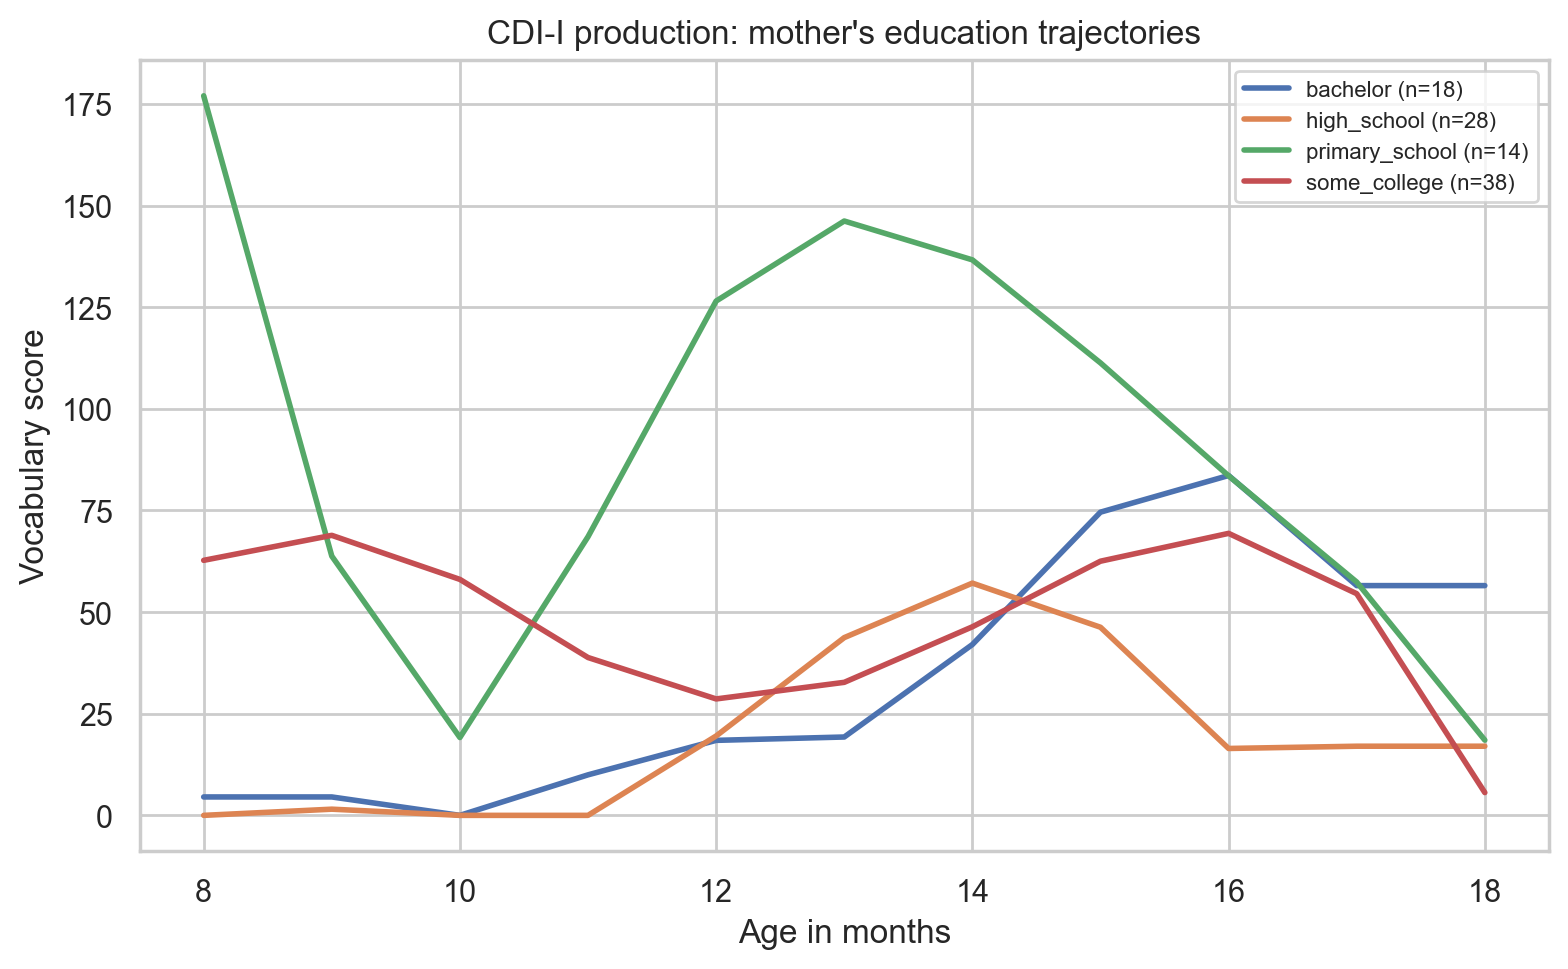

In [29]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'categories' / 'cdi1_production_education.png'))


## Category-Level Trajectories


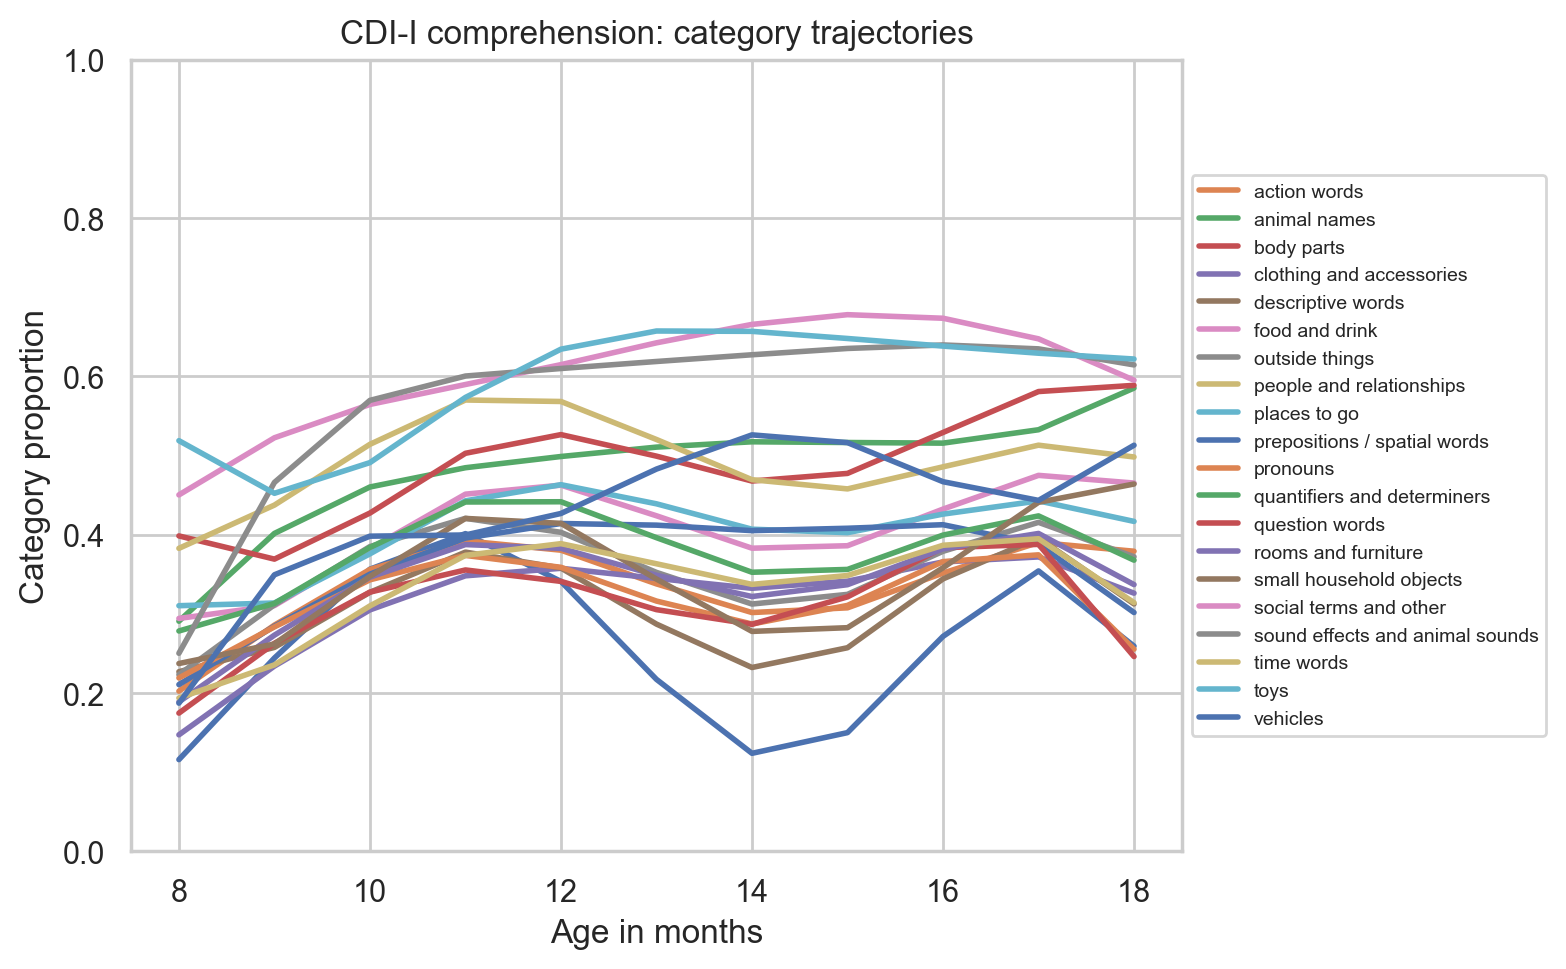

In [30]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'categories' / 'cdi1_comprehension_categories.png'))


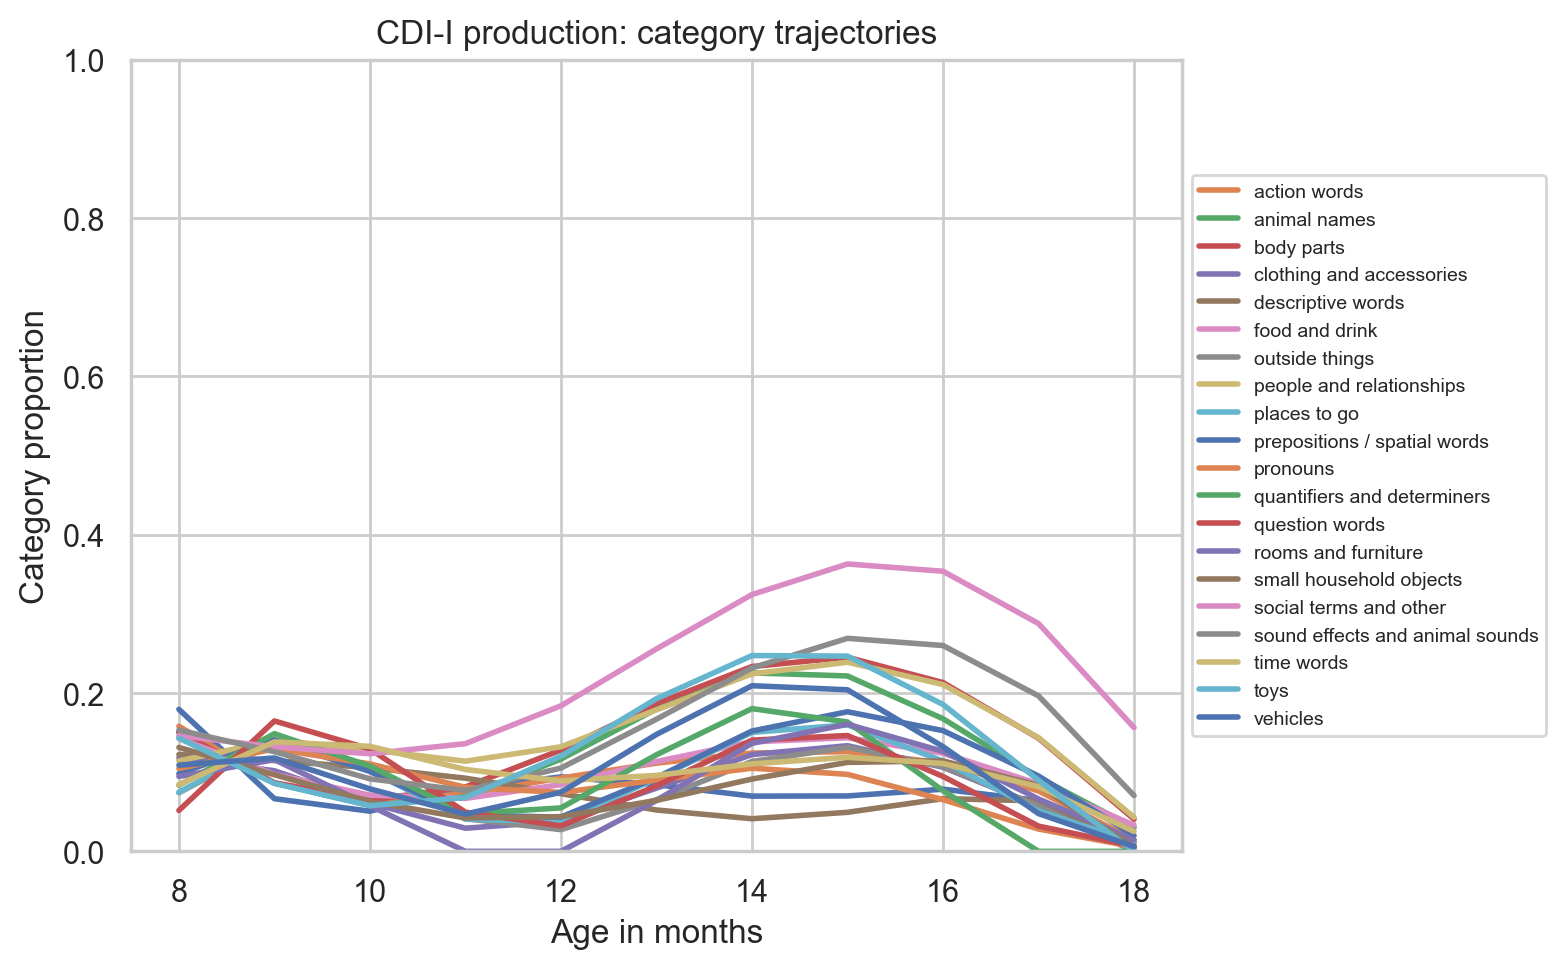

In [31]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'categories' / 'cdi1_production_categories.png'))


## Item Trajectories


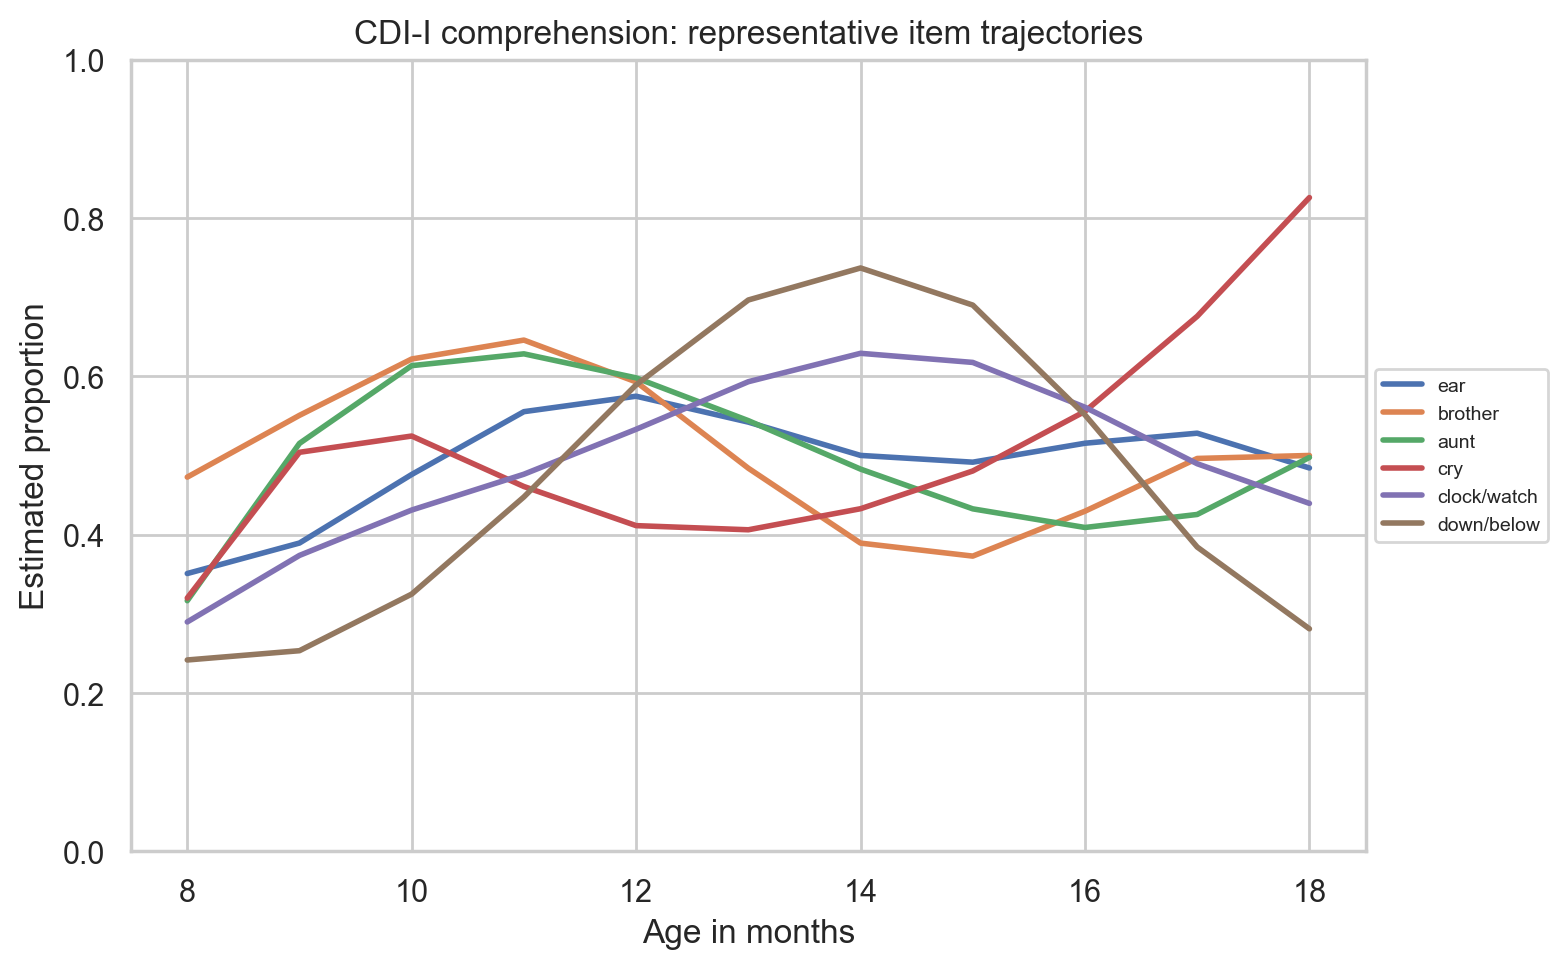

In [32]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'items' / 'cdi1_comprehension_items.png'))


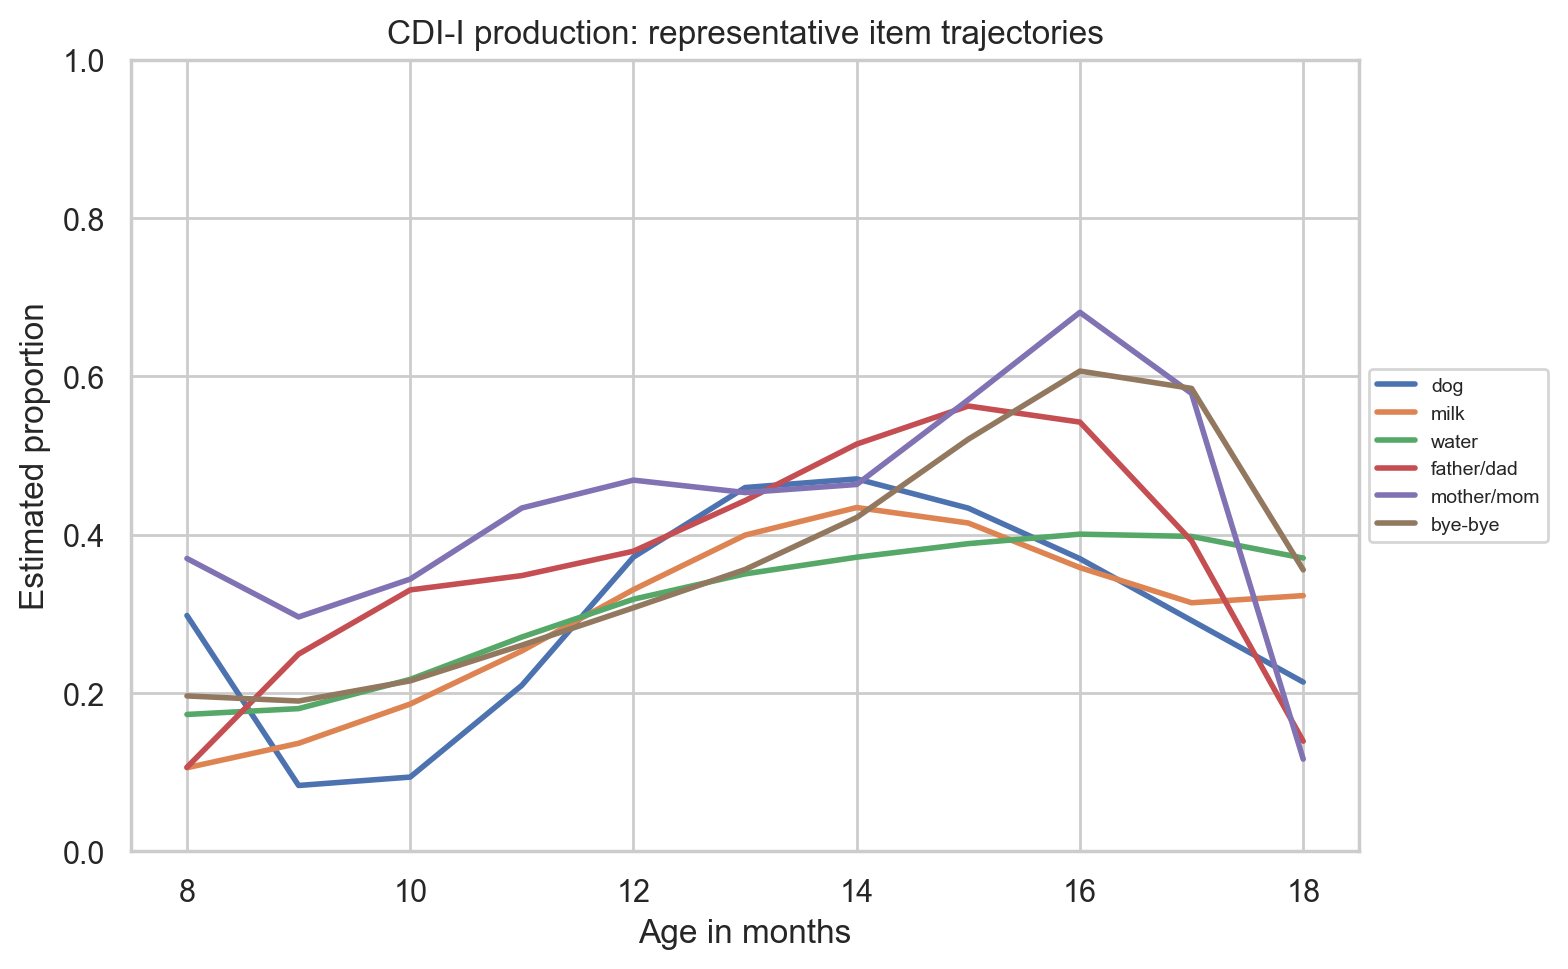

In [33]:
Image(filename=str(outputs_dir / 'figures' / 'cdi1' / 'items' / 'cdi1_production_items.png'))


In [34]:
render_item_widget(items, 'understand', list(range(8, 19)), 'CDI-I comprehension item trajectory')


In [35]:
render_item_widget(items, 'produce', list(range(8, 19)), 'CDI-I production item trajectory')


## Exported Output Inventory


In [36]:
sorted(str(path.relative_to(repo_root)) for path in [p for p in (outputs_dir / 'tables' / 'cdi1').glob('*.csv')] + [p for p in (outputs_dir / 'figures' / 'cdi1' / 'comprehension').glob('*.png')] + [p for p in (outputs_dir / 'figures' / 'cdi1' / 'production').glob('*.png')] + [p for p in (outputs_dir / 'figures' / 'cdi1' / 'items').glob('*.png')] + [p for p in (outputs_dir / 'figures' / 'cdi1' / 'categories').glob('*.png')])


['outputs\\figures\\cdi1\\categories\\cdi1_comprehension_categories.png',
 'outputs\\figures\\cdi1\\categories\\cdi1_comprehension_education.png',
 'outputs\\figures\\cdi1\\categories\\cdi1_production_categories.png',
 'outputs\\figures\\cdi1\\categories\\cdi1_production_education.png',
 'outputs\\figures\\cdi1\\comprehension\\cdi1_comprehension_deciles.png',
 'outputs\\figures\\cdi1\\comprehension\\cdi1_comprehension_overall.png',
 'outputs\\figures\\cdi1\\comprehension\\cdi1_comprehension_quartiles.png',
 'outputs\\figures\\cdi1\\comprehension\\cdi1_comprehension_sample_size.png',
 'outputs\\figures\\cdi1\\comprehension\\cdi1_comprehension_score_distribution.png',
 'outputs\\figures\\cdi1\\comprehension\\cdi1_comprehension_selected_quantiles.png',
 'outputs\\figures\\cdi1\\comprehension\\cdi1_comprehension_sex_selected_quantiles.png',
 'outputs\\figures\\cdi1\\items\\cdi1_comprehension_items.png',
 'outputs\\figures\\cdi1\\items\\cdi1_production_items.png',
 'outputs\\figures\\cdi1\\